In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [ ]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [ ]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [ ]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [ ]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Exited'])
y = df['Exited']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

# hidden layer + input
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
# output layer
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
# validation_split=0.2 -> 8000 - 20% -> Test on 20% along
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7294 - loss: 0.5514 - val_accuracy: 0.8019 - val_loss: 0.4771
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8005 - loss: 0.4600 - val_accuracy: 0.8044 - val_loss: 0.4497
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8034 - loss: 0.4414 - val_accuracy: 0.8062 - val_loss: 0.4347
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8075 - loss: 0.4297 - val_accuracy: 0.8087 - val_loss: 0.4238
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8148 - loss: 0.4183 - val_accuracy: 0.8206 - val_loss: 0.4120
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8266 - loss: 0.4054 - val_accuracy: 0.8313 - val_loss: 0.3969
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8380 - loss: 0.3904 - val_accuracy: 0.8425 - val_loss: 0.3820
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8442 - loss: 0.3764 - val_accu

In [ ]:
model.layers[0].get_weights()

[array([[-0.71789265, -0.07126255, -0.0630709 , -0.01659141,  0.262849  ,
          0.39805058,  0.30108812,  0.25804394, -0.0104636 , -0.26072094,
         -0.19177715],
        [ 0.1462461 ,  0.94848377,  0.30333987,  0.04872922,  0.20055543,
         -0.46062708, -0.26116788, -0.45545185,  0.5289839 ,  0.91400903,
          1.2743803 ],
        [-0.04932433, -0.27180222,  0.23827185,  0.02677992,  0.62817055,
         -0.64308435,  0.6176052 ,  0.5700302 , -0.30134973,  0.47570613,
         -0.07326372],
        [-0.20382746,  0.10925101, -0.01034585,  0.21567541,  0.22467412,
         -0.21048509, -0.63746077, -0.45843843,  0.6125008 , -0.6218159 ,
          0.32560772],
        [-0.11737219, -0.623359  , -0.00371206,  0.9247692 , -0.33512834,
          0.6756028 , -0.6864282 ,  0.7045821 , -0.06921275, -0.25810856,
          0.4060272 ],
        [-0.5688486 ,  0.37662485,  0.8205498 , -0.08202668, -0.3891289 ,
          0.01306769, -0.27367425, -0.35236192,  0.7777467 , -0.2439504

In [ ]:
model.layers[1].get_weights()

[array([[-0.10184167, -0.81863   ,  0.7412629 ,  0.5059536 ,  0.0481815 ,
          0.37379548, -0.03875253,  0.49284923, -0.02689248,  0.34758082,
          0.30198136],
        [ 0.18531807, -0.5044445 ,  0.33522418, -0.11528257, -0.41820627,
          0.3057591 , -0.4344297 , -0.3595198 , -0.51291245, -0.74483967,
         -0.06142782],
        [ 0.14847179, -0.24533999,  0.3913913 , -0.1012183 ,  0.33333707,
         -0.2372782 , -0.45429534,  0.3525604 , -0.37417883, -0.04754063,
         -0.24506606],
        [ 0.94707346,  0.4722661 ,  0.8413359 , -0.7838554 , -0.7663715 ,
         -0.5258367 , -1.0052214 , -0.34701675,  0.9824881 , -0.05484952,
         -0.16302685],
        [ 0.22556108,  0.27415222,  0.10266041,  0.17090125,  0.47304514,
         -0.11804681, -0.25437188,  0.22877781,  0.59140694, -0.14559738,
          0.05008295],
        [-0.42468965,  0.50384986,  0.38601276,  0.39708692,  0.45790648,
          0.27422765,  0.10763133, -0.01449346,  0.21504818,  0.2723398

In [ ]:
model.layers[2].get_weights()

[array([[ 1.3136255 ],
        [ 1.0808231 ],
        [ 0.8730361 ],
        [-0.3710565 ],
        [-0.8531888 ],
        [ 0.791119  ],
        [-1.1615962 ],
        [-1.0704387 ],
        [ 0.3972798 ],
        [-0.47871596],
        [-0.49606243]], dtype=float32),
 array([0.02901829], dtype=float32)]

In [ ]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Threshold if <0.5 -> 0 else 1 
y_pred = np.where(y_log>0.5,1,0)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.863

In [ ]:
import matplotlib.pyplot as plt
history.history

{'accuracy': [0.7293750047683716,
  0.8004687428474426,
  0.8034374713897705,
  0.8075000047683716,
  0.8148437738418579,
  0.8265625238418579,
  0.8379687666893005,
  0.8442187309265137,
  0.8520312309265137,
  0.8514062762260437,
  0.8543750047683716,
  0.8559374809265137,
  0.8550000190734863,
  0.8568750023841858,
  0.8565624952316284,
  0.8576562404632568,
  0.8584374785423279,
  0.8598437309265137,
  0.8596875071525574,
  0.8596875071525574,
  0.859375,
  0.8606250286102295,
  0.8610937595367432,
  0.8610937595367432,
  0.8604687452316284,
  0.8607812523841858,
  0.8606250286102295,
  0.8612499833106995,
  0.8623437285423279,
  0.8612499833106995,
  0.8628125190734863,
  0.8621875047683716,
  0.8620312213897705,
  0.8618749976158142,
  0.8612499833106995,
  0.8623437285423279,
  0.862500011920929,
  0.8618749976158142,
  0.8614062666893005,
  0.8615624904632568,
  0.8635937571525574,
  0.8618749976158142,
  0.8620312213897705,
  0.8631250262260437,
  0.8639062643051147,
  0.86265

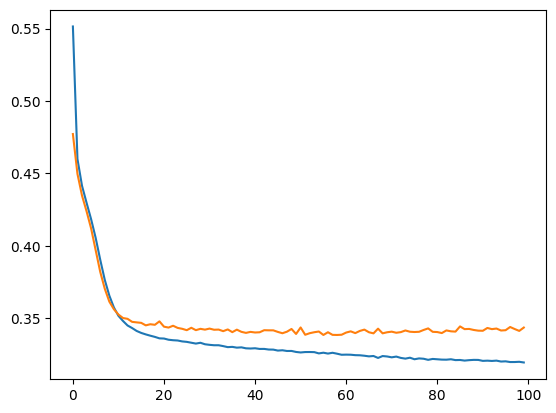

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

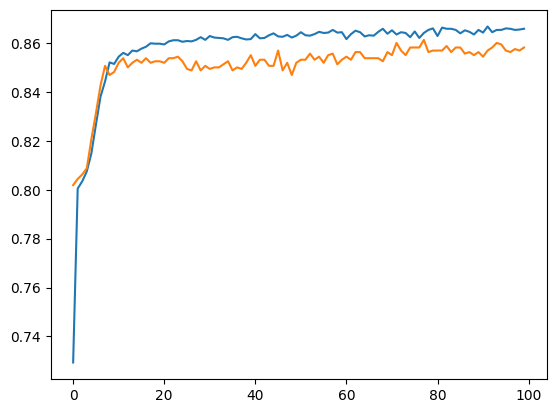

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])